1. Write a Python script for Weather Data Analysis:
Problem Statement:
You have a CSV file named 'weather_data.csv' containing daily weather data for a city.

Date Temperature
(°C)
Humidity
(%)
Wind
Speed
(km/h)
Rainfall
(mm)

01-01-2025 15.2 80 10.5 0

02-01-2025 16.8 75 8 0

03-01-2025 14.5 85 12 1.2

04-01-2025 13 90 15.2 5.4


05-01-2025 17.6 70 7.4 0

06-01-2025 18.1 65 6 0

07-01-2025 16.2 78 9.1 0.5

08-01-2025 12.4 88 14.3 2.1

09-01-2025 13.8 83 11.5 0

10-01-2025 15.5 79 10 0


Perform the following tasks:

a. Check for missing values and handle them appropriately,

b. Calculate the average temperature for each month,

c. Visualize the monthly average temperature using a bar plot

In [1]:
import pandas as pd
import io

csv_data = """Date,Temperature (°C),Humidity (%),Wind Speed (km/h),Rainfall (mm)
01-01-2025,15.2,80,10.5,0
02-01-2025,16.8,75,8,0
03-01-2025,14.5,85,12,1.2
04-01-2025,13,90,15.2,5.4
05-01-2025,17.6,70,7.4,0
06-01-2025,18.1,65,6,0
07-01-2025,16.2,78,9.1,0.5
08-01-2025,12.4,88,14.3,2.1
09-01-2025,13.8,83,11.5,0
10-01-2025,15.5,79,10,0
"""

# Save the data to a CSV file
with open('weather_data.csv', 'w') as f:
    f.write(csv_data)

print("weather_data.csv created successfully.")

# Load the CSV into a DataFrame
df = pd.read_csv('weather_data.csv')

# Convert 'Date' column to datetime objects
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')

display(df.head())

weather_data.csv created successfully.


,Date,Temperature (°C),Humidity (%),Wind Speed (km/h),Rainfall (mm)
0,2025-01-01,15.2,80,10.5,0.0
1,2025-01-02,16.8,75,8.0,0.0
2,2025-01-03,14.5,85,12.0,1.2
3,2025-01-04,13.0,90,15.2,5.4
4,2025-01-05,17.6,70,7.4,0.0


### Task a: Check for missing values and handle them appropriately.

In [2]:
# Check for missing values
missing_values = df.isnull().sum()
print("Missing values in each column:")
print(missing_values)

# In this specific dataset, there are no missing values.
# If there were, common strategies include:
# 1. Imputation (e.g., df.fillna(df.mean(), inplace=True) for numerical columns)
# 2. Dropping rows/columns with missing values (e.g., df.dropna(inplace=True))
# For now, no action is needed as there are no missing values.

Missing values in each column:
Date                 0
Temperature (°C)     0
Humidity (%)         0
Wind Speed (km/h)    0
Rainfall (mm)        0
dtype: int64


### Task b: Calculate the average temperature for each month.

In [3]:
# Extract month from the 'Date' column
df['Month'] = df['Date'].dt.month

# Calculate the average temperature for each month
monthly_avg_temp = df.groupby('Month')['Temperature (°C)'].mean().reset_index()

display(monthly_avg_temp)

,Month,Temperature (°C)
0,1,15.31


### Task c: Visualize the monthly average temperature using a bar plot.

/tmp/ipykernel_2383/2241782681.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Month_Name', y='Temperature (°C)', data=monthly_avg_temp, palette='viridis')


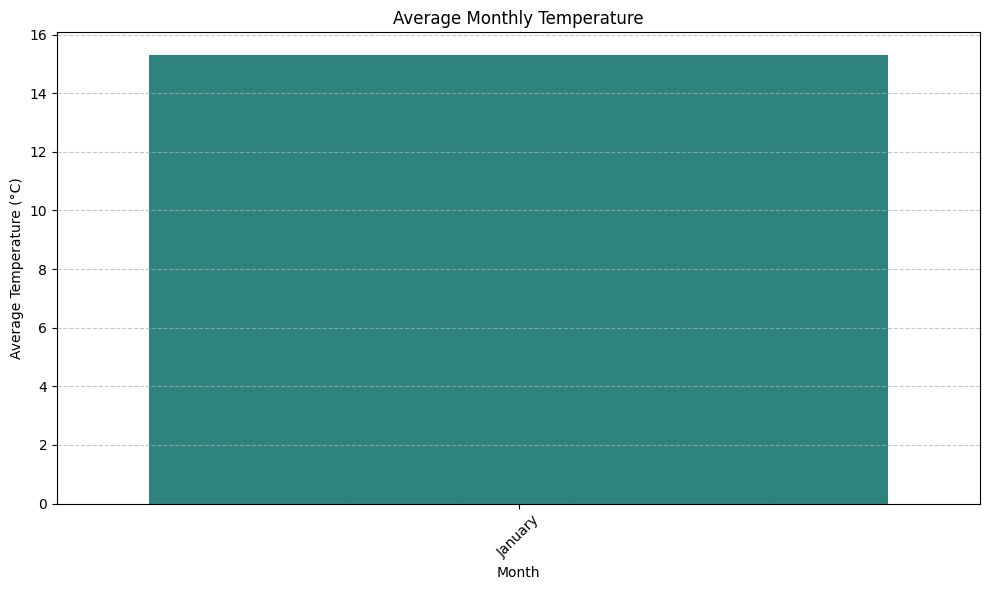

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Map month numbers to month names for better readability
month_names = {1: 'January', 2: 'February', 3: 'March', 4: 'April', 5: 'May', 6: 'June',
               7: 'July', 8: 'August', 9: 'September', 10: 'October', 11: 'November', 12: 'December'}
monthly_avg_temp['Month_Name'] = monthly_avg_temp['Month'].map(month_names)

# Create the bar plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Month_Name', y='Temperature (°C)', data=monthly_avg_temp, palette='viridis')
plt.title('Average Monthly Temperature')
plt.xlabel('Month')
plt.ylabel('Average Temperature (°C)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()